In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import scanpy as sc 
import anndata as ad 
import xarray as xr
import geopandas as gpd
import glob

sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))

datadir = '../../UC/UC-data'

In [9]:
cells = pd.read_csv(f'{datadir}/IBD_CODEX_190825_k100_nc14_Cells.csv')
metadata = pd.read_csv(f'{datadir}/2024_10_16_UC_Patient_Metadata.csv')
markernames = [m for m in cells.columns if 'Cyc' in m]

In [10]:
# divide all X and Y values by 2.65
# (we observed empirically that the coordinates in the CSV file are off from those in the original image by this scaling factor)
cells[['X:X','Y:Y']] /= 2.65

In [11]:
# massage the data in cells to look nice
sid = cells['File Name'].str.split("_", expand=True)[[0, 3]].rename(columns={0: 'Run#', 3: 'Region #'})
sid['Run#'] = sid['Run#'].replace({'Eigth': 8, 'First': 1, 'Second': 2, 'Seventh': 7, 'Sixth': 6, 'Third': 3})
sid['Region #'] = sid['Region #'].replace({'reg[0]+': ''}, regex=True).astype(np.int64)
sid = sid.merge(metadata[['Run#', 'Region #', 'NEW Label']], on=['Run#', 'Region #'], how='left')
cells['sid'] = sid['NEW Label']
cells['batch'] = sid['Run#']
cells['cid'] = cells['sid'].str.cat((cells.groupby(['sid']).cumcount() + 1).astype(str), sep="_")
cells.rename(columns={'X:X': 'x', 'Y:Y': 'y'}, inplace=True)

clustermap = {36066: 'Epithelium',
    36070: 'Mixed_Stroma',
    36061: 'Tcells',
    36069: 'Granulocytes',
    36073: 'Plasmacells',
    36062: 'Vessels',
    36063: 'Neutrophils',
    36065: 'Smoothmuscle',
    36067: 'Bcells',
    36072: 'zDirt',
    36074: 'Follicular_CD4Tcells',
    36064: 'Epithelium_Ki67',
    36071: 'DCs',
    36068: 'Intraepithelial_Tcells'} # Sourced from Derek's email
cells['celltype'] = cells.ClusterID.map(clustermap)
print(cells.celltype.isna().sum(), 'untyped cells')

cells = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(x=cells['x'], y=cells['y']))

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_17758/1471237197.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sid['Run#'] = sid['Run#'].replace({'Eigth': 8, 'First': 1, 'Second': 2, 'Seventh': 7, 'Sixth': 6, 'Third': 3})


0 untyped cells


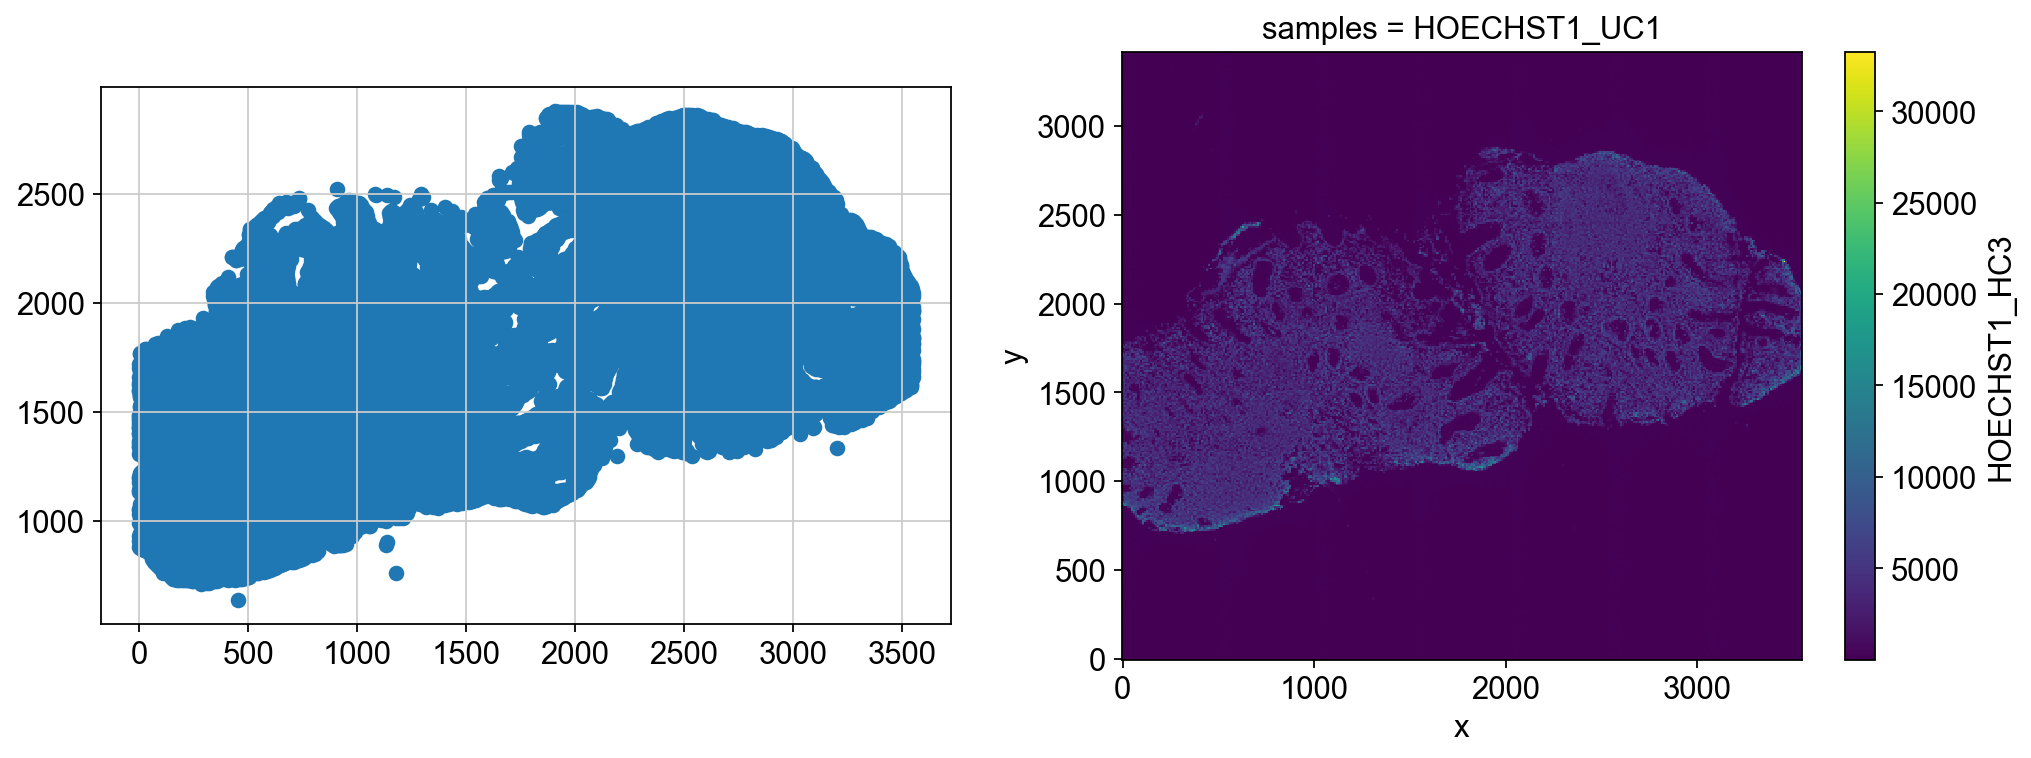

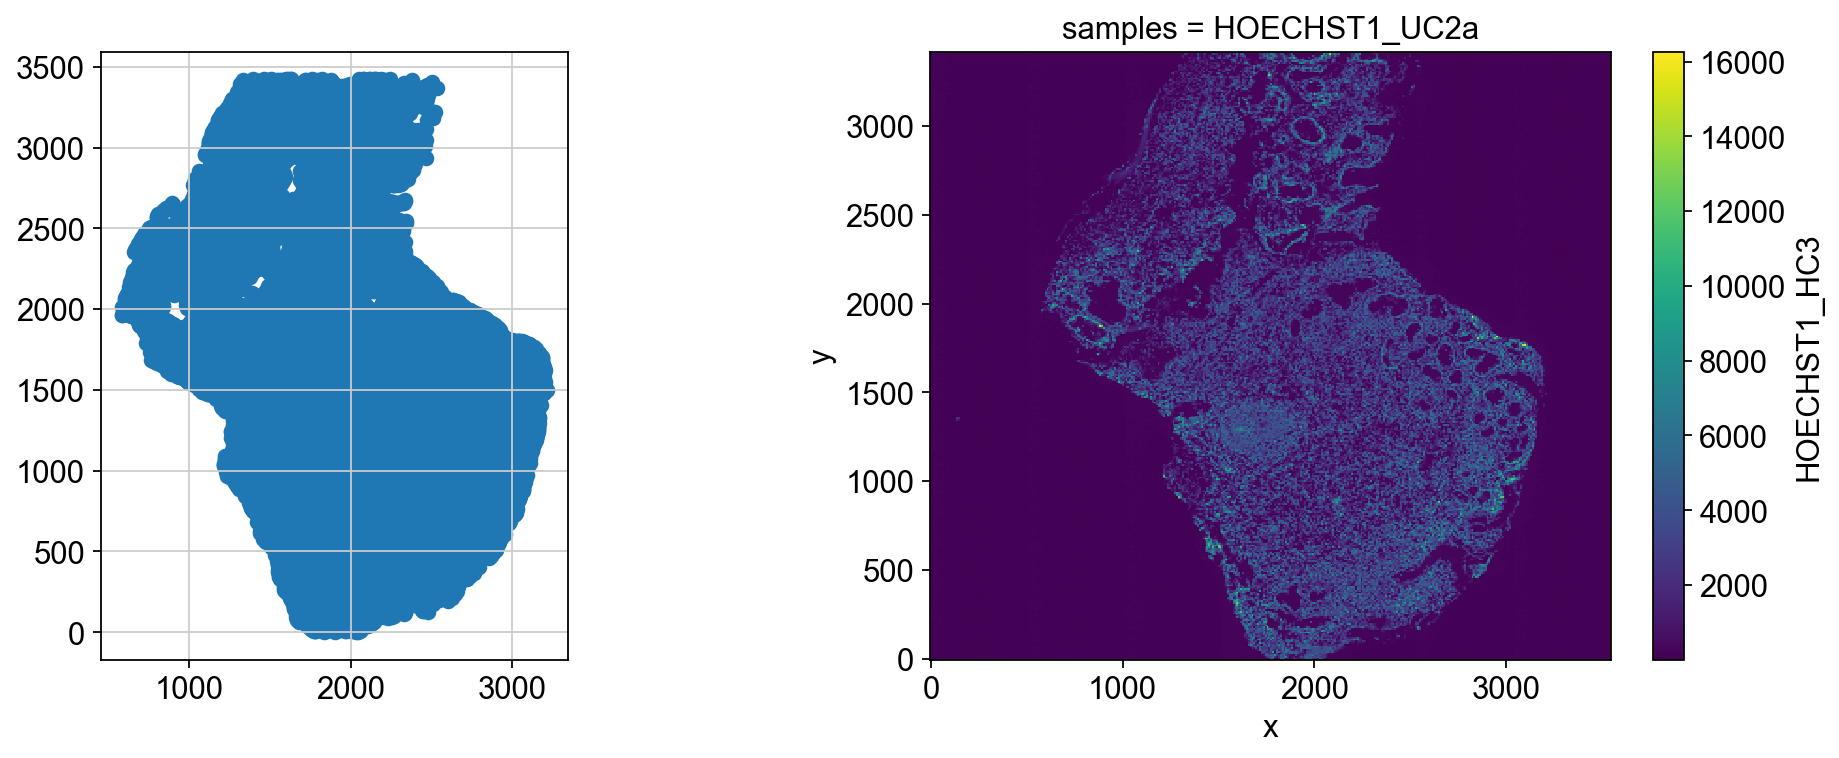

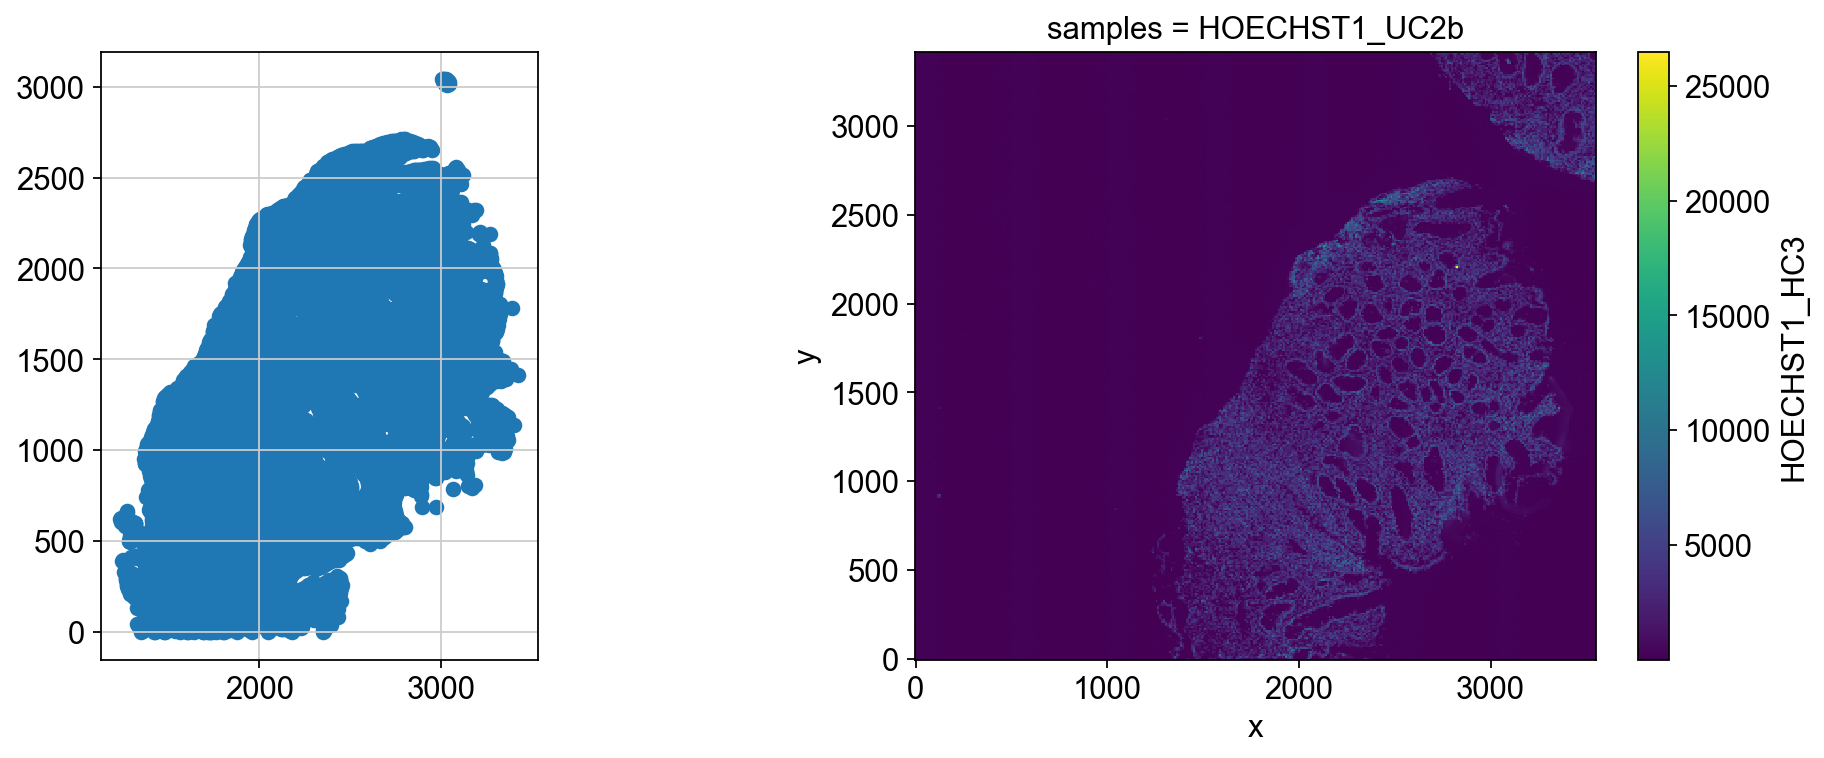

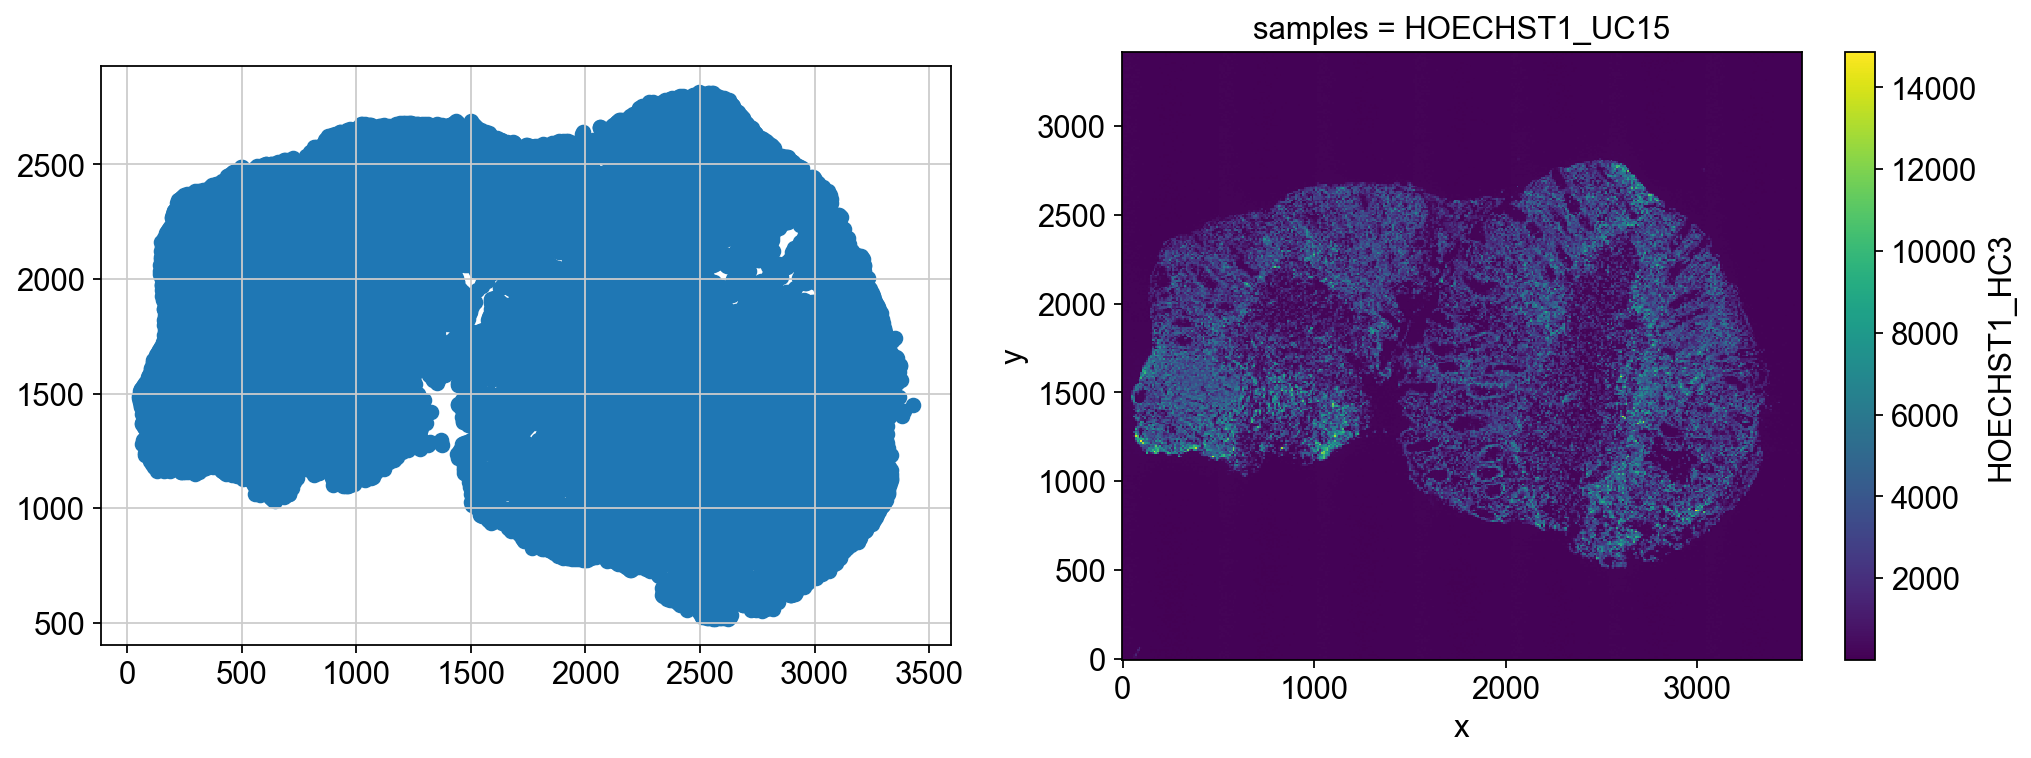

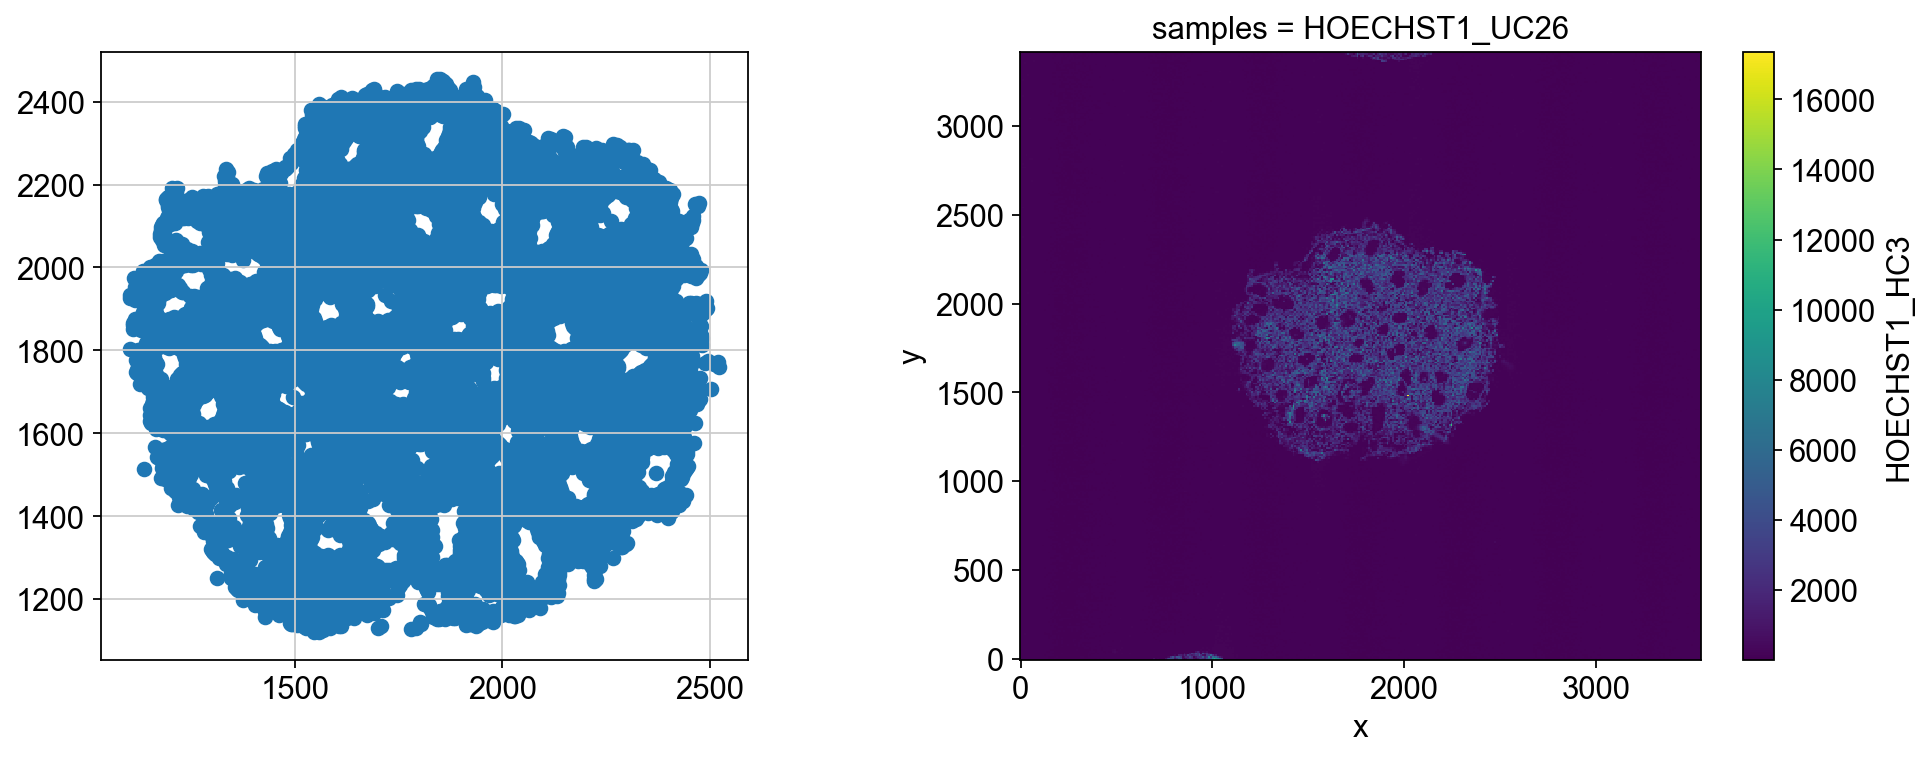

In [14]:
# Marker for comparison between cell locations and stain locations 
def extract_marker(s, stain): 
    res = s.sel(marker=stain).rename(f"{stain}_{s.name}")
    res = res.rename({"marker": "samples"}).assign_coords({"samples": f"{stain}_{s.name}"})
    return(res)

hoechst = xr.concat(
    [extract_marker(xr.open_dataarray(file), stain='HOECHST1') for file in glob.glob(f'{datadir}/10u/counts/*')], 
    dim='samples'
)

for sid in cells.sid.unique()[:5]: 
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    
    subset = cells[cells.sid == sid]
    subset.plot(ax=ax[0])

    hoechst.sel(samples=f'HOECHST1_{sid}').plot(ax=ax[1])

In [15]:
# cell QC
markers = cells.filter(regex='Cyc')
norm_markers = (markers - markers.mean(axis=0))/markers.std(axis=0)

## Filtering out cells that were overstained or understained by nuc 
nuc_stain_mask = np.abs(norm_markers[['DRAQ5:Cyc_20_ch_4', 'HOECHST1:Cyc_1_ch_1']]) > 5
nuc_stain_mask = nuc_stain_mask['DRAQ5:Cyc_20_ch_4'] | nuc_stain_mask['HOECHST1:Cyc_1_ch_1']

markers = markers.drop(['DRAQ5:Cyc_20_ch_4', 'HOECHST1:Cyc_1_ch_1'], axis=1)
min_total_exp_mask = markers.sum(axis=1) < 500 
even_exp_mask = markers.gt(0.5 * markers.sum(axis=1), axis=0)
even_exp_mask = even_exp_mask.sum(axis=1)
exclude_mask = nuc_stain_mask | min_total_exp_mask | even_exp_mask

## Final cells object for downstream analysis
cells = cells.loc[~exclude_mask]

In [16]:
d = sc.AnnData(X=cells[markernames].values, obs=cells[['sid', 'batch', 'cid', 'celltype']].copy())
d.obsm['spatial'] = cells[['x', 'y']].values
d.obs.set_index('cid', drop=True, inplace=True)
d.write(f'{datadir}/IBD_CODEX_190825_k100_nc14_Cells.filtered_typed.h5ad')

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Unused

In [ ]:
# code for determining the ratio of spatial units between the segmented cells and the raw CODEX data
fname = cells['File Name'].unique()[10]
print(fname)
mycells = cells[cells['File Name'] == fname]
cxs = mycells['X:X'].values
cys = mycells['Y:Y'].values
print(cxs.min(), cxs.max(), cys.min(), cys.max())

mask = xr.load_dataarray(f'{datadir}/10u/masks/HC3.nc')
mask.plot(); plt.show()
xs = mask.x[np.where(mask.data > 0)[1]]
ys = mask.y[np.where(mask.data > 0)[0]]
print(xs.min(), xs.max(), ys.min(), ys.max())